In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
deliveries = pd.read_csv('/content/drive/MyDrive/DS/deliveries.csv')
matches = pd.read_csv('/content/drive/MyDrive/DS/matches.csv')

In [ ]:
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,5/4/2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,6/4/2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,7/4/2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,8/4/2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,8/4/2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [ ]:
deliveries.head()


,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [ ]:
deliveries.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [ ]:
matches.isnull().sum()


,0
id,0
season,0
city,7
date,0
team1,0
team2,0
toss_winner,0
toss_decision,0
result,0
dl_applied,0


In [ ]:
matches['winner'].fillna('No Result', inplace=True)

/tmp/ipykernel_1055/1247128743.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['winner'].fillna('No Result', inplace=True)


In [ ]:
wins = matches['winner'].value_counts()

print(wins)

winner
Mumbai Indians                 92
Chennai Super Kings            79
Kolkata Knight Riders          77
Royal Challengers Bangalore    73
Kings XI Punjab                70
Rajasthan Royals               63
Delhi Daredevils               62
Sunrisers Hyderabad            42
Deccan Chargers                29
Gujarat Lions                  13
Pune Warriors                  12
Rising Pune Supergiant         10
Kochi Tuskers Kerala            6
Rising Pune Supergiants         5
No Result                       3
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

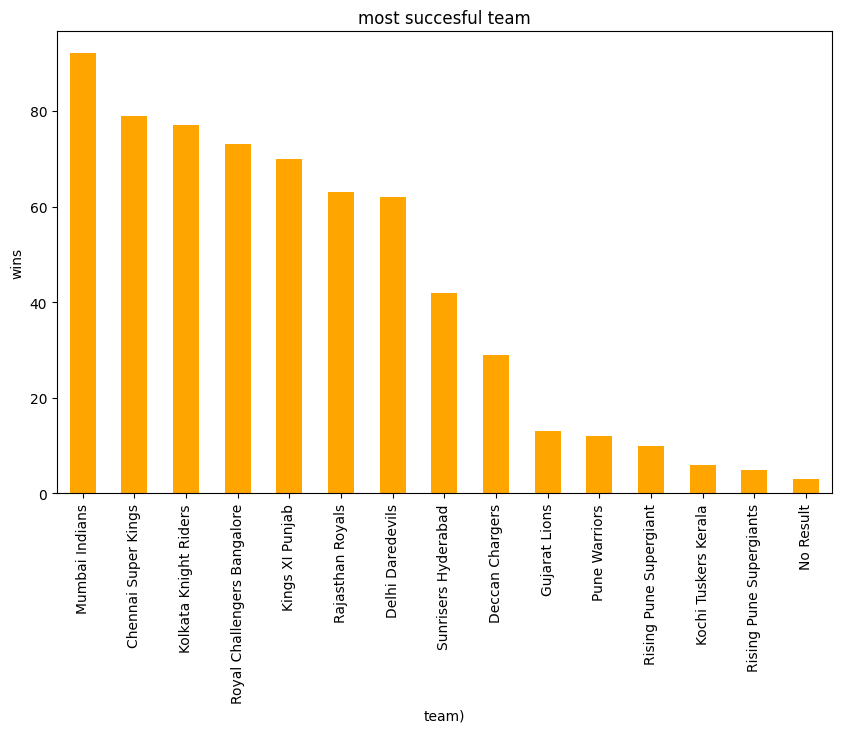

In [ ]:
plt.figure(figsize=(10,6))
wins.plot(kind='bar',color='orange')
plt.title('most succesful team')
plt.xlabel('team)')
plt.ylabel('wins')
plt.xticks(rotation=90)
plt.show

In [ ]:
toss_match_wins = matches[matches['toss_winner']==matches['winner']] .shape[0]
total_matches=matches.shape[0]
print("toss winner also won matches",toss_match_wins)
print("win pecentage",(toss_match_wins/total_matches)*100)


toss winner also won matches 325
win pecentage 51.100628930817614


/tmp/ipykernel_1055/278307890.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scorers.index, y=top_scorers.values, palette="coolwarm")


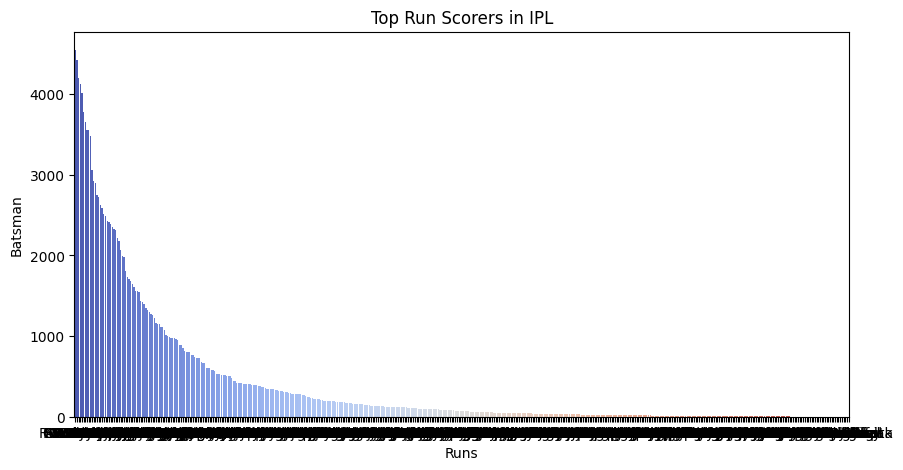

In [ ]:
top_scorers = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=top_scorers.index, y=top_scorers.values, palette="coolwarm")
plt.title("Top Run Scorers in IPL")
plt.xlabel("Runs")
plt.ylabel("Batsman")
plt.show()

/tmp/ipykernel_1055/1383668420.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bowlers.index, y=top_bowlers.values, palette="magma")


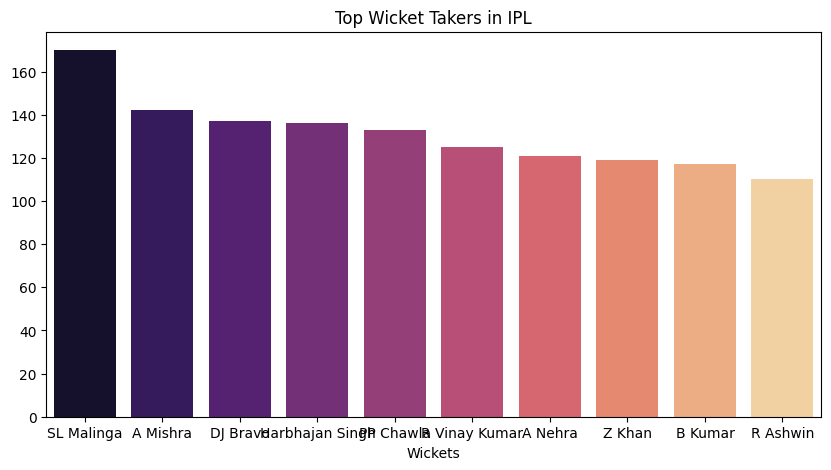

In [ ]:
wickets = deliveries[deliveries['dismissal_kind'].notnull()]
top_bowlers = wickets['bowler'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_bowlers.index, y=top_bowlers.values, palette="magma")
plt.title("Top Wicket Takers in IPL")
plt.xlabel("Wickets")
plt.show()


In [ ]:
runs=deliveries.groupby('batsman')['batsman_runs'].sum()
balls=deliveries.groupby('batsman')['ball'].count()
strike_rate = (runs/balls)*100
print(strike_rate.sort_values(ascending=False).head(10))


batsman
DL Chahar        233.333333
Umar Gul         205.263158
RS Sodhi         200.000000
BCJ Cutting      177.142857
AJ Tye           176.666667
Shahid Afridi    176.086957
I Malhotra       175.000000
SN Khan          171.844660
CR Brathwaite    169.642857
LJ Wright        168.253968
dtype: float64


In [ ]:
bowler_runs = deliveries.groupby('bowler')['total_runs'].sum()
bowler_balls = deliveries.groupby('bowler')['ball'].count()
overs= bowler_balls/6
economy = (bowler_runs/overs)
print(economy.sort_values().head(10))

bowler
AC Gilchrist     0.000000
N Rana           3.000000
NB Singh         4.320000
Sachin Baby      4.800000
AM Rahane        5.000000
LA Carseldine    5.142857
SS Mundhe        5.142857
Mohammad Nabi    5.363636
DJ Thornely      5.454545
Avesh Khan       6.000000
dtype: float64
